### Import Dataset From Drive

- Test: https://drive.google.com/file/d/1ALveidCmKzk4p_liQ7b663BXL0PcTaFN/view?usp=drive_link
- Train: https://drive.google.com/file/d/1Ujh37a1kTarNf3dSOSrj-hKDswULebYA/view?usp=drive_link

In [1]:
import pandas as pd

In [2]:
!gdown --id '1ALveidCmKzk4p_liQ7b663BXL0PcTaFN'
test = pd.read_csv('test_transaction.csv')

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1ALveidCmKzk4p_liQ7b663BXL0PcTaFN
From (redirected): https://drive.google.com/uc?id=1ALveidCmKzk4p_liQ7b663BXL0PcTaFN&confirm=t&uuid=f4e7c559-4139-4743-a950-5dab071558a1
To: /content/test_transaction.csv
100% 613M/613M [00:09<00:00, 64.9MB/s]


In [3]:
!gdown --id '1Ujh37a1kTarNf3dSOSrj-hKDswULebYA'
train = pd.read_csv('train_transaction.csv')

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Ujh37a1kTarNf3dSOSrj-hKDswULebYA
From (redirected): https://drive.google.com/uc?id=1Ujh37a1kTarNf3dSOSrj-hKDswULebYA&confirm=t&uuid=98ac3ee0-f77d-4143-b701-c09fe7d211d5
To: /content/train_transaction.csv
100% 683M/683M [00:11<00:00, 61.0MB/s]


### Check dataset

In [4]:
test.shape

(506691, 393)

In [5]:
train.shape

(590540, 394)

### Check IsFraud

In [6]:
train['isFraud'].head(5)

,isFraud
0,0
1,0
2,0
3,0
4,0


### Import lib

pytorch-tabnet dipilih karena:
  - Dirancang khusus untuk tabular data (bukan image/text)
  - Attention-based: otomatis seleksi fitur yang relevan
  - Jauh lebih ringan dari MLP besar atau Transformer penuh
  - Built-in support untuk imbalanced data via weights

In [7]:
!pip install pytorch-tabnet -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.0 MB/s eta 0:00:00


Aktifkan GPU di Colab: Runtime -> Change runtime type -> GPU

In [8]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import gc
import warnings
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
  roc_auc_score, average_precision_score,
  classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')

In [9]:
# Cek device -> GPU lebih cepat tapi CPU tetap bisa jalan
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device yang digunakan: {device}")
print(f"PyTorch version: {torch.__version__}")

Device yang digunakan: cuda
PyTorch version: 2.10.0+cu128


### Mem Reduction Function

In [10]:
# Downcast tipe data numerik ke ukuran terkecil yang muat
# -> hemat 50-70% RAM sebelum data masuk ke model.

def reduce_mem_usage(df):
  for col in df.columns:
    col_type = df[col].dtype
    if col_type != object:
      c_min = df[col].min()
      c_max = df[col].max()
      if str(col_type)[:3] == 'int':
        if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
          df[col] = df[col].astype(np.int8)
        elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
          df[col] = df[col].astype(np.int16)
        elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
          df[col] = df[col].astype(np.int32)
      else:
        if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
          df[col] = df[col].astype(np.float16)
        elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
          df[col] = df[col].astype(np.float32)
  return df


###  EDA Singkat

Fokus pada 3 hal penting:

- Distribusi target (class imbalance)
- Persentase missing value per kolom
- Tipe data kolom

In [11]:
fraud_counts = train['isFraud'].value_counts()
fraud_ratio  = train['isFraud'].value_counts(normalize=True) * 100

In [12]:
# class distribution
print(fraud_counts)
print(f"\nFraud rate: {fraud_ratio[1]:.2f}%")

isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.50%


In [13]:
# check missing
missing_pct = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].head(20))

dist2    93.628374
D7       93.409930
D13      89.509263
D14      89.469469
D12      89.041047
D6       87.606767
D8       87.312290
D9       87.312290
V162     86.123717
V142     86.123717
V146     86.123717
V147     86.123717
V141     86.123717
V138     86.123717
V163     86.123717
V161     86.123717
V154     86.123717
V153     86.123717
V158     86.123717
V157     86.123717
dtype: float64


In [14]:
# check data type
print(train.dtypes.value_counts())

float64    376
object      14
int64        4
Name: count, dtype: int64


In [15]:
# check TransactionAmt
print(train['TransactionAmt'].describe())

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64


### Preprocessing

Hal yang perlu diperhatikan:
  - TabNet WAJIB input float32 (bukan float16/int8)
  - Missing value fill 0 lebih aman untuk neural network
    </br> (nilai -999 bisa ganggu gradient flow)
  - Semua kolom harus numerik (label encode kategori)

Categorical index perlu dipisah dan diberitahu ke TabNet <br>
supaya model tahu kolom mana yang perlu embedding.

In [16]:
test_ids = test['TransactionID'].copy()

y = train['isFraud'].copy().values.astype(int)
X = train.drop(['isFraud', 'TransactionID'], axis=1)
X_test = test.drop(['TransactionID'], axis=1)

del train, test
gc.collect()

0

In [17]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print(f"Numerical  : {len(num_cols)}")
print(f"Categorical: {len(cat_cols)}")


Numerical  : 378
Categorical: 14


In [18]:
# Fill missing
# 0 dipilih untuk DL karena neural network sensitif terhadap nilai ekstrem
X[num_cols]      = X[num_cols].fillna(0)
X_test[num_cols] = X_test[num_cols].fillna(0)
X[cat_cols]      = X[cat_cols].fillna('unknown')
X_test[cat_cols] = X_test[cat_cols].fillna('unknown')

In [19]:
# Label Encoding (fit gabungan train+test)
for col in cat_cols:
  le = LabelEncoder()
  combined = pd.concat([X[col], X_test[col]], axis=0).astype(str)
  le.fit(combined)
  X[col]      = le.transform(X[col].astype(str))
  X_test[col] = le.transform(X_test[col].astype(str))

In [20]:
# TabNet butuh semua kolom dalam float32
X      = X.astype(np.float32)
X_test = X_test.astype(np.float32)

In [21]:
# Identifikasi posisi kolom kategori (TabNet pakai index, bukan nama)
cat_idxs = [X.columns.get_loc(c) for c in cat_cols]

In [22]:
# Hitung cardinality tiap kolom kategori (jumlah unique value + 1)
# +1 untuk buffer unknown category
cat_dims = [int(X.iloc[:, i].max()) + 1 for i in cat_idxs]

In [23]:
print(f"\nX shape     : {X.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"cat_idxs    : {len(cat_idxs)} kolom")


X shape     : (590540, 392)
X_test shape: (506691, 392)
cat_idxs    : 14 kolom


### Feature Engineering

In [24]:
group_cols = ['card1', 'card4', 'card6', 'P_emaildomain']

for col in group_cols:
  if col in X.columns:
    amt_mean_map = X.groupby(col)['TransactionAmt'].mean()
    amt_std_map  = X.groupby(col)['TransactionAmt'].std()

    X[f'{col}_amt_mean'] = X[col].map(amt_mean_map).astype(np.float32)
    X[f'{col}_amt_std']  = X[col].map(amt_std_map).astype(np.float32)

    X_test[f'{col}_amt_mean'] = X_test[col].map(amt_mean_map).astype(np.float32)
    X_test[f'{col}_amt_std']  = X_test[col].map(amt_std_map).astype(np.float32)

if 'TransactionDT' in X.columns:
  X['hour']      = ((X['TransactionDT'] / 3600) % 24).astype(np.float32)
  X['day']       = ((X['TransactionDT'] / (3600 * 24)) % 7).astype(np.float32)
  X_test['hour'] = ((X_test['TransactionDT'] / 3600) % 24).astype(np.float32)
  X_test['day']  = ((X_test['TransactionDT'] / (3600 * 24)) % 7).astype(np.float32)

X['TransactionAmt_log']      = np.log1p(X['TransactionAmt']).astype(np.float32)
X_test['TransactionAmt_log'] = np.log1p(X_test['TransactionAmt']).astype(np.float32)

In [25]:
# Fill NaN dari aggregasi (grup di test yang tidak ada di train)
X      = X.fillna(0).astype(np.float32)
X_test = X_test.fillna(0).astype(np.float32)

In [26]:
# Convert ke numpy (TabNet butuh numpy array, bukan DataFrame)
X_np      = X.values
X_test_np = X_test.values

In [27]:
gc.collect()
print(f"X numpy shape     : {X_np.shape}")
print(f"X_test numpy shape: {X_test_np.shape}")

X numpy shape     : (590540, 403)
X_test numpy shape: (506691, 403)


 ### Training TabNet

Arsitektur TabNet:
  - n_d & n_a     : dimensi representasi (lebih kecil = lebih ringan)
  - n_steps        : jumlah step attention (seperti "depth")
  - gamma          : koefisien feature reusage antar step
  - n_independent & n_shared: jumlah layer per step

Setting yang dipilih (ringan untuk Colab free):
  - n_d=n_a=32    : representasi cukup ekspresif tapi tidak berat
  - n_steps=3     : 3 step attention (default 3-5)
  - batch_size=4096: besar untuk throughput, kecil untuk RAM
  - virtual_batch_size=256: Ghost Batch Normalization

 Class imbalance diatasi via class_weight:
  - Kelas fraud (1) diberi bobot lebih tinggi
  </br>-> Model lebih "peduli" terhadap kesalahan pada kelas minoritas

In [28]:
# Hitung class weight untuk imbalance
neg = (y == 0).sum()
pos = (y == 1).sum()

In [29]:
# Bobot invers frekuensi: kelas langka dapat bobot lebih besar
class_weight = {0: 1.0, 1: neg / pos}
print(f"Class weight -> 0: {class_weight[0]:.1f}, 1: {class_weight[1]:.1f}")

Class weight -> 0: 1.0, 1: 27.6


In [30]:
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

In [31]:
oof_preds  = np.zeros(len(X_np))
test_preds = np.zeros(len(X_test_np))
fold_aucs  = []

In [32]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X_np, y)):
  print(f"\n{'='*45}")
  print(f"  FOLD {fold+1} / 5")
  print(f"{'='*45}")

  X_train, X_val = X_np[train_idx], X_np[val_idx]
  y_train, y_val = y[train_idx],    y[val_idx]

  # Sample weight per row (lebih fleksibel dari class_weight dict)
  sample_weights = np.where(y_train == 1, class_weight[1], class_weight[0])

  model = TabNetClassifier(
    n_d                = 32,      # dimensi decision step output
    n_a                = 32,      # dimensi attention embedding
    n_steps            = 3,       # jumlah sequential attention steps
    gamma              = 1.3,     # feature reuse coefficient
    n_independent      = 2,       # independent layers per step
    n_shared           = 2,       # shared layers per step
    cat_idxs           = cat_idxs,
    cat_dims           = cat_dims,
    cat_emb_dim        = 1,       # embedding dim per kategori (kecil = hemat)
    optimizer_fn       = torch.optim.Adam,
    optimizer_params   = {'lr': 2e-3, 'weight_decay': 1e-5},
    scheduler_fn       = torch.optim.lr_scheduler.StepLR,
    scheduler_params   = {'step_size': 10, 'gamma': 0.9},
    mask_type          = 'sparsemax',  # attention sparsity (interpretable)
    device_name        = device,
    verbose            = 10,      # print tiap 10 epoch
    seed               = 42,
  )

  model.fit(
    X_train, y_train,
    eval_set           = [(X_val, y_val)],
    eval_name          = ['val'],
    eval_metric        = ['auc'],
    max_epochs         = 10,
    patience           = 3,              # early stopping: stop jika 15 epoch tidak improve
    batch_size         = 64,
    virtual_batch_size = 64,             # Ghost Batch Norm batch size
    weights            = sample_weights,
    drop_last          = False,
  )

  # Prediksi probabilitas kelas 1 (fraud)
  oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
  test_preds        += model.predict_proba(X_test_np)[:, 1] / 5

  fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
  fold_aucs.append(fold_auc)
  print(f"  -> Fold {fold+1} AUC: {fold_auc:.4f}")

  # Simpan model tiap fold (opsional, bisa di-comment kalau storage terbatas)
  model.save_model(f'tabnet_fold{fold+1}')

  del X_train, X_val, y_train, y_val, sample_weights, model
  torch.cuda.empty_cache()
  gc.collect()


  FOLD 1 / 5
epoch 0  | loss: 0.52144 | val_auc: 0.85492 |  0:03:43s
Stop training because you reached max_epochs = 10 with best_epoch = 9 and best_val_auc = 0.92047
  -> Fold 1 AUC: 0.9205
Successfully saved model at tabnet_fold1.zip

  FOLD 2 / 5
epoch 0  | loss: 0.53548 | val_auc: 0.85707 |  0:03:21s
Stop training because you reached max_epochs = 10 with best_epoch = 9 and best_val_auc = 0.9214
  -> Fold 2 AUC: 0.9214
Successfully saved model at tabnet_fold2.zip


In [33]:
overall_auc = roc_auc_score(y, oof_preds)
print(f"\n{'='*45}")
print(f"  Fold AUCs : {[f'{a:.4f}' for a in fold_aucs]}")
print(f"  Mean AUC  : {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"  OOF AUC   : {overall_auc:.4f}")
print(f"{'='*45}")


  Fold AUCs : ['0.9205', '0.9214']
  Mean AUC  : 0.9209 ± 0.0005
  OOF AUC   : 0.9206


### Evaluasi

Metrik:
  1. ROC-AUC  -> threshold-agnostic, metrik utama fraud detection
  2. PR-AUC   -> lebih informatif untuk imbalanced class
  3. Classification Report -> precision, recall, F1 per kelas
  4. Confusion Matrix -> breakdown TP/TN/FP/FN

Interpretasi untuk fraud detection:
  - FN (False Negative) = fraud lolos -> paling berbahaya
  - FP (False Positive) = transaksi normal diblokir -> ganggu user

Threshold 0.5 bisa disesuaikan tergantung toleransi bisnis.

In [34]:
oof_binary = (oof_preds >= 0.5).astype(int)

In [35]:
# ROC-AUC Score
print(f"ROC-AUC Score: {roc_auc_score(y, oof_preds):.4f}")

ROC-AUC Score: 0.9206


In [36]:
# PR-AUC Average Precision
print(f"PR-AUC Average Precision:   {average_precision_score(y, oof_preds):.4f}")

PR-AUC Average Precision:   0.5608


In [37]:
# Classification Report
print(classification_report(y, oof_binary, target_names=['Not Fraud', 'Fraud']))

              precision    recall  f1-score   support

   Not Fraud       0.99      0.89      0.94    569877
       Fraud       0.21      0.80      0.34     20663

    accuracy                           0.89    590540
   macro avg       0.60      0.85      0.64    590540
weighted avg       0.96      0.89      0.92    590540



In [38]:
# Confusion matrix
cm = confusion_matrix(y, oof_binary)
print(f"   TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"   FN={cm[1,0]:,}  TP={cm[1,1]:,}")
print("\n   FN = Fraud lolos (paling berbahaya)")
print("   FP = Normal salah diblokir (ganggu user)")

   TN=508,841  FP=61,036
   FN=4,134  TP=16,529

   FN = Fraud lolos (paling berbahaya)
   FP = Normal salah diblokir (ganggu user)


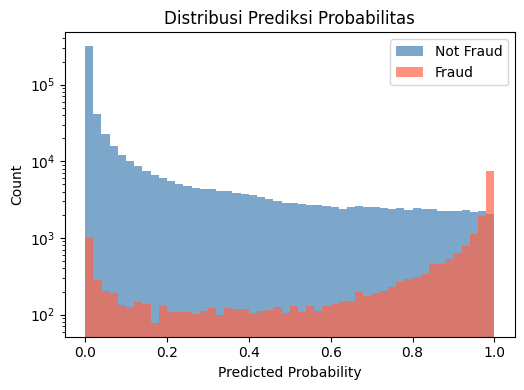

In [39]:
# --- Plot distribusi prediksi ---
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(oof_preds[y == 0], bins=50, alpha=0.7, label='Not Fraud', color='steelblue')
plt.hist(oof_preds[y == 1], bins=50, alpha=0.7, label='Fraud',     color='tomato')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Distribusi Prediksi Probabilitas')
plt.legend()
plt.yscale('log')  # log scale karena imbalanced

plt.tight_layout()
plt.savefig('tabnet_evaluation.png', dpi=80)
plt.show()

### Hyperparameter Tuning

Parameter TabNet yang paling impactful:
  - n_d / n_a  : ukuran representasi (kompleksitas model)
  - n_steps    : kedalaman attention mechanism
  - learning_rate: step size optimizer

Strategi hemat resource:
  - Pakai 20% data saja untuk tuning
  - max_epochs dibatasi 30 (bukan 100)
  - patience dikecilkan ke 5
  - Tidak pakai CV, cukup single train-val split

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
# Ambil 20% data untuk tuning
X_tune, _, y_tune, _ = train_test_split(
  X_np, y, test_size=0.8, stratify=y, random_state=42
)

In [42]:
# Split tune set jadi train/val (80/20)
X_t, X_v, y_t, y_v = train_test_split(
  X_tune, y_tune, test_size=0.2, stratify=y_tune, random_state=42
)

In [43]:
sample_weights_tune = np.where(y_t == 1, class_weight[1], class_weight[0])

In [44]:
print(f"Tuning data: {len(X_t):,} train | {len(X_v):,} val\n")

param_grid = [
  {'n_d': 16, 'n_steps': 3, 'lr': 2e-3},
  {'n_d': 32, 'n_steps': 3, 'lr': 2e-3},
  {'n_d': 32, 'n_steps': 4, 'lr': 1e-3},
  {'n_d': 64, 'n_steps': 3, 'lr': 1e-3},
]

tuning_results = []

Tuning data: 94,486 train | 23,622 val



In [45]:
for p in param_grid:
  print(f"Testing: n_d={p['n_d']}, n_steps={p['n_steps']}, lr={p['lr']}")

  tune_model = TabNetClassifier(
    n_d              = p['n_d'],
    n_a              = p['n_d'],   # n_a selalu sama dengan n_d
    n_steps          = p['n_steps'],
    gamma            = 1.3,
    n_independent    = 2,
    n_shared         = 2,
    cat_idxs         = cat_idxs,
    cat_dims         = cat_dims,
    cat_emb_dim      = 1,
    optimizer_fn     = torch.optim.Adam,
    optimizer_params = {'lr': p['lr'], 'weight_decay': 1e-5},
    mask_type        = 'sparsemax',
    device_name      = device,
    verbose          = 0,   # silent untuk tuning
    seed             = 42,
  )

  tune_model.fit(
    X_t, y_t,
    eval_set           = [(X_v, y_v)],
    eval_name          = ['val'],
    eval_metric        = ['auc'],
    max_epochs         = 30,
    patience           = 5,
    batch_size         = 4096,
    virtual_batch_size = 256,
    weights            = sample_weights_tune,
    drop_last          = False,
  )

  val_auc = roc_auc_score(y_v, tune_model.predict_proba(X_v)[:, 1])
  tuning_results.append({**p, 'val_auc': val_auc})
  print(f"  -> Val AUC: {val_auc:.4f}\n")

  del tune_model
  torch.cuda.empty_cache()
  gc.collect()

Testing: n_d=16, n_steps=3, lr=0.002
Stop training because you reached max_epochs = 30 with best_epoch = 29 and best_val_auc = 0.83681
  -> Val AUC: 0.8368

Testing: n_d=32, n_steps=3, lr=0.002
Stop training because you reached max_epochs = 30 with best_epoch = 29 and best_val_auc = 0.85366
  -> Val AUC: 0.8537

Testing: n_d=32, n_steps=4, lr=0.001
Stop training because you reached max_epochs = 30 with best_epoch = 29 and best_val_auc = 0.79232
  -> Val AUC: 0.7923

Testing: n_d=64, n_steps=3, lr=0.001
Stop training because you reached max_epochs = 30 with best_epoch = 29 and best_val_auc = 0.83878
  -> Val AUC: 0.8388



In [46]:
tuning_df = pd.DataFrame(tuning_results).sort_values('val_auc', ascending=False)

print("Hasil Tuning")
print(tuning_df.to_string(index=False))
print(f"\nBest config: n_d={tuning_df.iloc[0]['n_d']:.0f}, "
      f"n_steps={tuning_df.iloc[0]['n_steps']:.0f}, "
      f"lr={tuning_df.iloc[0]['lr']}")

Hasil Tuning
 n_d  n_steps    lr  val_auc
  32        3 0.002 0.853663
  64        3 0.001 0.838777
  16        3 0.002 0.836809
  32        4 0.001 0.792318

Best config: n_d=32, n_steps=3, lr=0.002


### Submission

- test_preds = rata-rata probabilitas dari 5 fold (ensemble)
- Format output: TransactionID + isFraud probability

In [47]:
submission = pd.DataFrame({
  'TransactionID': test_ids,
  'isFraud'      : test_preds
})

submission.to_csv('submission_tabnet.csv', index=False)

print("=== Submission Preview ===")
print(submission.head(10))
print(f"\nTotal rows    : {len(submission):,}")
print(f"isFraud range : [{submission['isFraud'].min():.4f}, {submission['isFraud'].max():.4f}]")
print(f"Mean isFraud  : {submission['isFraud'].mean():.4f}")
print("\nsubmission_tabnet.csv berhasil dibuat.")

=== Submission Preview ===
   TransactionID   isFraud
0        3663549  0.000139
1        3663550  0.000173
2        3663551  0.000830
3        3663552  0.000254
4        3663553  0.000928
5        3663554  0.012566
6        3663555  0.054649
7        3663556  0.182647
8        3663557  0.001830
9        3663558  0.003314

Total rows    : 506,691
isFraud range : [0.0000, 0.4000]
Mean isFraud  : 0.0792

submission_tabnet.csv berhasil dibuat.
